# Classification of Depression Risk among Teens

By John Osorio

The goal is to build a classification model to predict depression risk in teenagers using social media usage and behavioral indicators.

Based on the public dataset *Teen Mental Health Dataset* https://www.kaggle.com/datasets/algozee/teenager-menthal-healy

## 1. Imports and data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
print(f'rows: {df.shape[0]}, cols: {df.shape[1]}')

rows: 1200, cols: 13


In [ ]:
df.head(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,1200.0,4.536667,2.029599,1.0,2.8,4.50,6.30,8.0
sleep_hours,1200.0,6.449417,1.442677,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1200.0,1.740333,0.716660,0.5,1.1,1.80,2.40,3.0
academic_performance,1200.0,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,1.014500,0.582185,0.0,0.5,1.00,1.50,2.0
stress_level,1200.0,5.445833,2.903290,1.0,3.0,5.00,8.00,10.0
anxiety_level,1200.0,5.636667,2.859453,1.0,3.0,6.00,8.00,10.0
addiction_level,1200.0,5.565000,2.830627,1.0,3.0,6.00,8.00,10.0
depression_label,1200.0,0.025833,0.158704,0.0,0.0,0.00,0.00,1.0


In [ ]:
df.isna().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [ ]:
print("Duplicated rows: ", df.duplicated().sum())

Duplicated rows:  0


## 2. Exploratory Data Analysis

Extracting relevant columns

In [ ]:
#target colum

target_col = 'depression_label'

#categorcal
cat_col = df.select_dtypes(include='object').columns.tolist()

#numerical
num_col = df.select_dtypes(include='number').columns.tolist()

if target_col in num_col:
    num_col.remove(target_col)

print(f"num_col: {num_col} \ncat_col: {cat_col}")

num_col: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level'] 
cat_col: ['gender', 'platform_usage', 'social_interaction_level']


Target column distribution

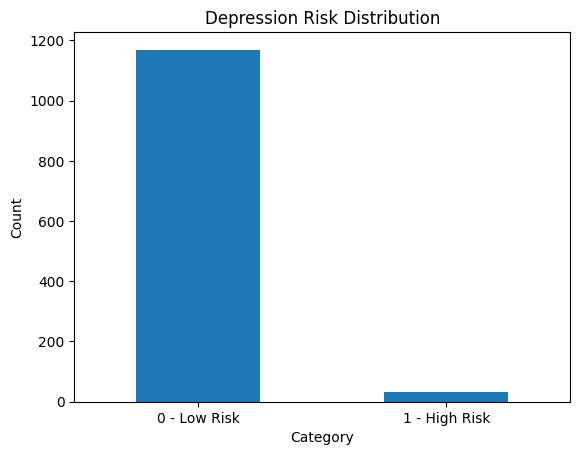

In [ ]:
ax = df[target_col].value_counts().sort_index().plot(kind='bar')
ax.set_xticklabels(["0 - Low Risk", "1 - High Risk"], rotation=0)
plt.title("Depression Risk Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

The dataset is imbalanced towards the first category, low risk. This has to be taken into account during the classification process.

Numerical columns distributions

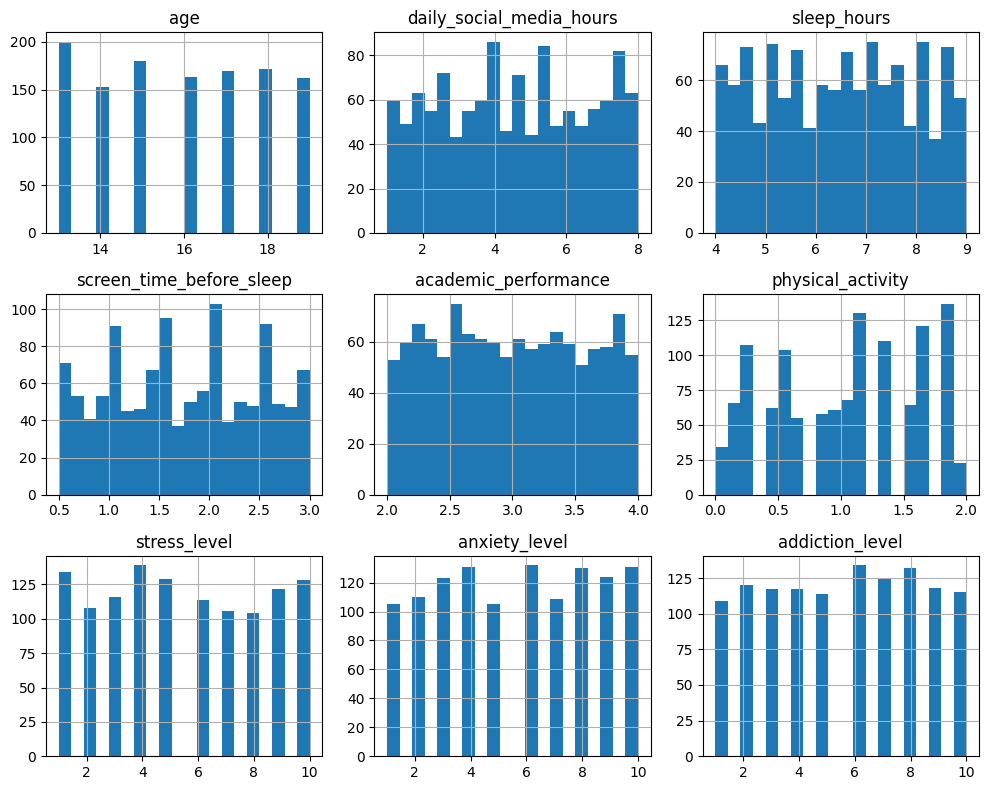

In [ ]:
df[num_col].hist(figsize=(10, 8), bins=20)

plt.tight_layout()
plt.show()

Relationship between target and important features

In [ ]:
features = num_col.copy()
features.remove("age")
features.remove("academic_performance")

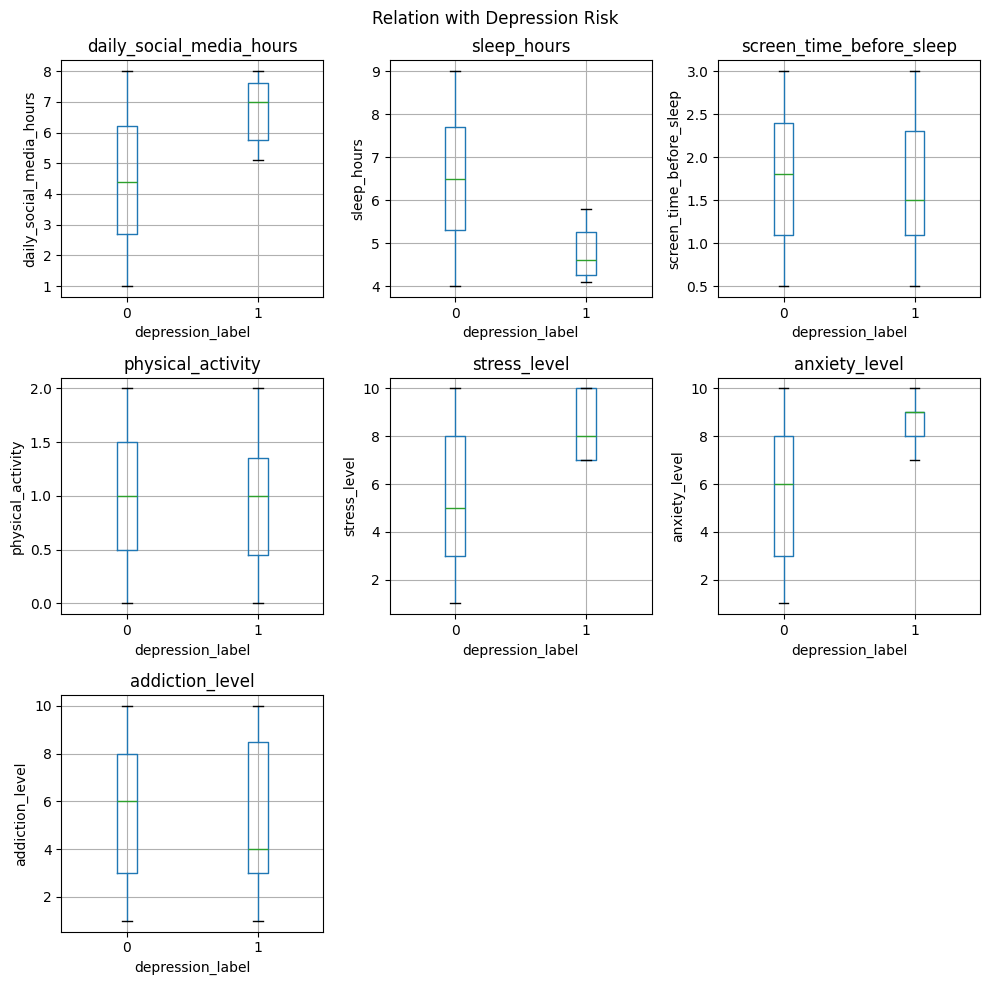

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by=target_col, ax=axes[i])
    axes[i].set_ylabel(f"{col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Relation with Depression Risk")
plt.tight_layout()
plt.show()

Correlation between variables

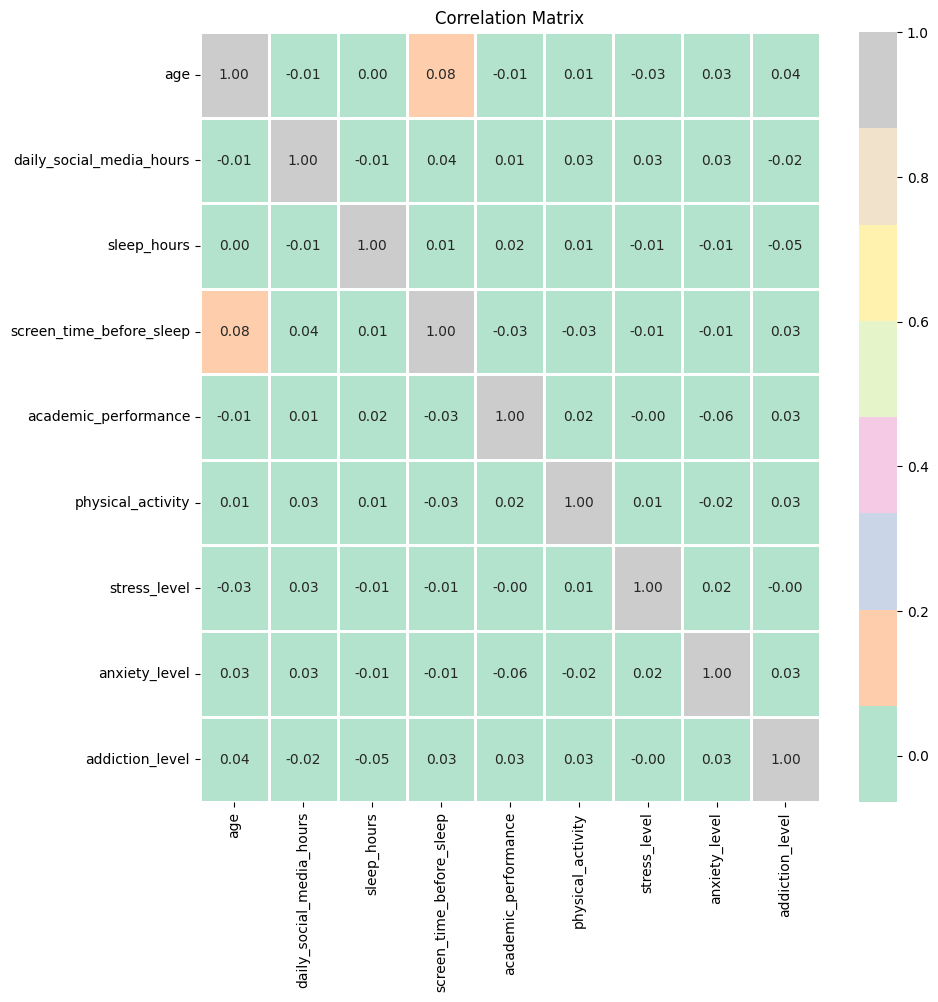

In [ ]:
plt.figure(figsize=(10, 10))

sns.heatmap(df[num_col].corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Matrix')
plt.show()

Distribution of categorical features

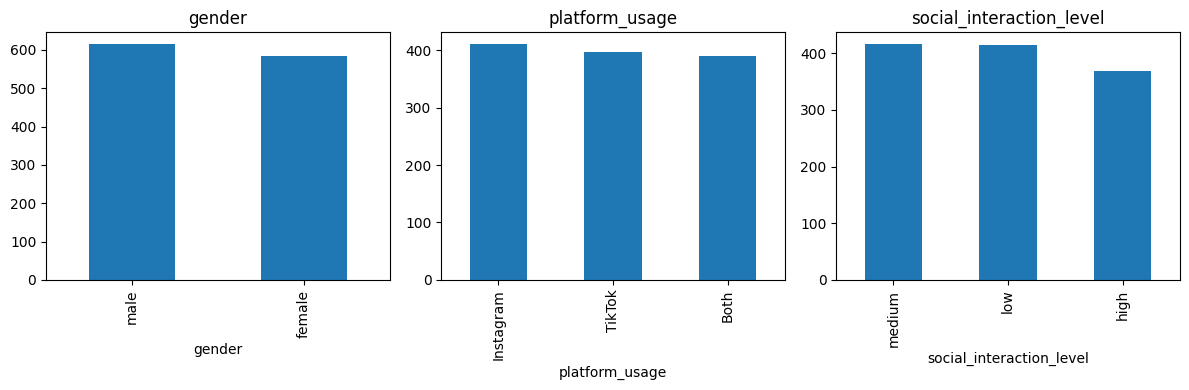

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Relation with target

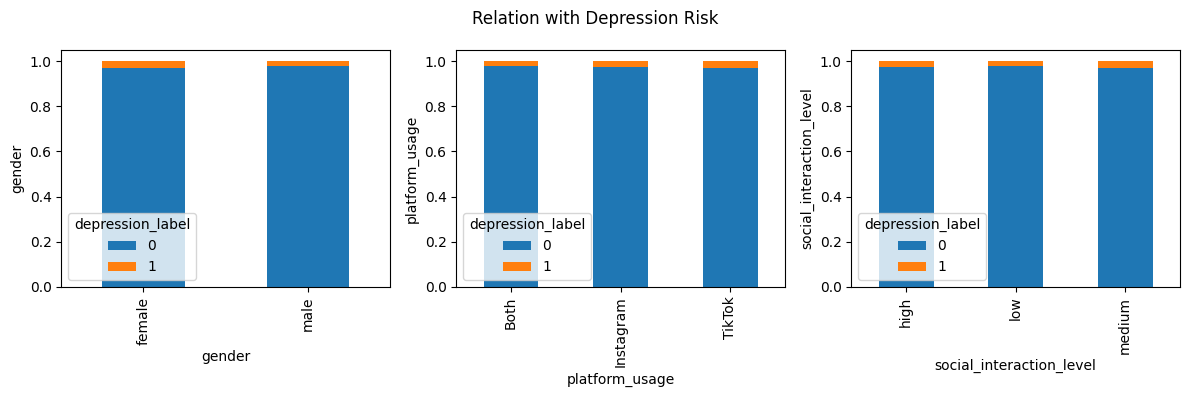

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes = axes.flatten()

for i, col in enumerate(cat_col):
  pd.crosstab(df[col], df[target_col], normalize='index').plot(kind='bar', stacked=True, ax=axes[i])
  axes[i].set_ylabel(f"{col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Relation with Depression Risk")
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

Label encoding for categories and standard scaling for numerical columns

In [ ]:
X = df.drop(target_col, axis=1)
y = df[target_col]

In [ ]:
le = LabelEncoder()
for col in cat_col:
  X[col] = le.fit_transform(X[col])

In [ ]:
scaler = StandardScaler()
X[num_col] = scaler.fit_transform(X[num_col])

In [ ]:
X.head(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,-0.954099,1,1.657833,1,0.659177,1.618830,0.034026,0.834276,1,-1.187367,-1.272335,-1.613389
1,1.519796,0,-1.299649,2,1.075244,1.618830,0.398282,-0.368593,0,0.880116,-1.622199,1.567444
2,0.530238,0,-1.595397,1,0.797866,-1.731436,1.612470,-1.743301,0,-1.187367,-0.572609,-1.259963
3,-0.459320,1,1.411376,2,0.312455,-0.195897,0.849266,-0.368593,2,-1.531947,0.476980,1.214018
4,-0.459320,0,0.080509,0,-1.074435,1.758424,-1.076088,0.662437,2,-0.842786,-0.222746,-1.259963


Splitting the dataset for training and testing, while tanking into account the imbalence "stratify=y"

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234, stratify=y)

Using SMOTE to handle the imbalanced dataset

In [ ]:
smote = SMOTETomek(random_state=1234)

X_train_smote,y_train_smote=smote.fit_resample(X_train, y_train)

## 4. Classification Models

Function to evaluate the metrics of a given model

In [ ]:
def eval_model(clf_model, X_train, X_test, y_train, y_test):
  clf_model.fit(X_train, y_train)
  y_pred = clf_model.predict(X_test)
  model_acc = accuracy_score(y_test, y_pred)
  model_pre = precision_score(y_test, y_pred)
  model_f1 = f1_score(y_test, y_pred)
  model_rec = recall_score(y_test, y_pred)
  model_cm = confusion_matrix(y_test, y_pred)

  return {'Accuracy': model_acc, 'Precision': model_pre, 'Recall': model_rec, 'F1_Score': model_f1}, model_cm

We will test four different classifiers

In [ ]:
Models = {
    'DecisionTreeClassifier': DecisionTreeClassifier(max_depth = 2, random_state = 1234,  class_weight="balanced"),
    'LogisticRegression': LogisticRegression(max_iter=10000, random_state = 1234),
    'RandomForestClassifier': RandomForestClassifier(max_depth = 2, random_state = 1234, class_weight="balanced"),
    'XGBClassifier': XGBClassifier(learning_rate=0.1)
}

In [ ]:
results = []
cmatrices = []
for name, model in Models.items():
  metrics, cm = eval_model(model, X_train_smote, X_test, y_train_smote, y_test)
  metrics = {'Model': name, **metrics}
  results.append(metrics)
  cmatrices.append(cm)
models_metrics = pd.DataFrame(results)

Confusion Matrices for all the models

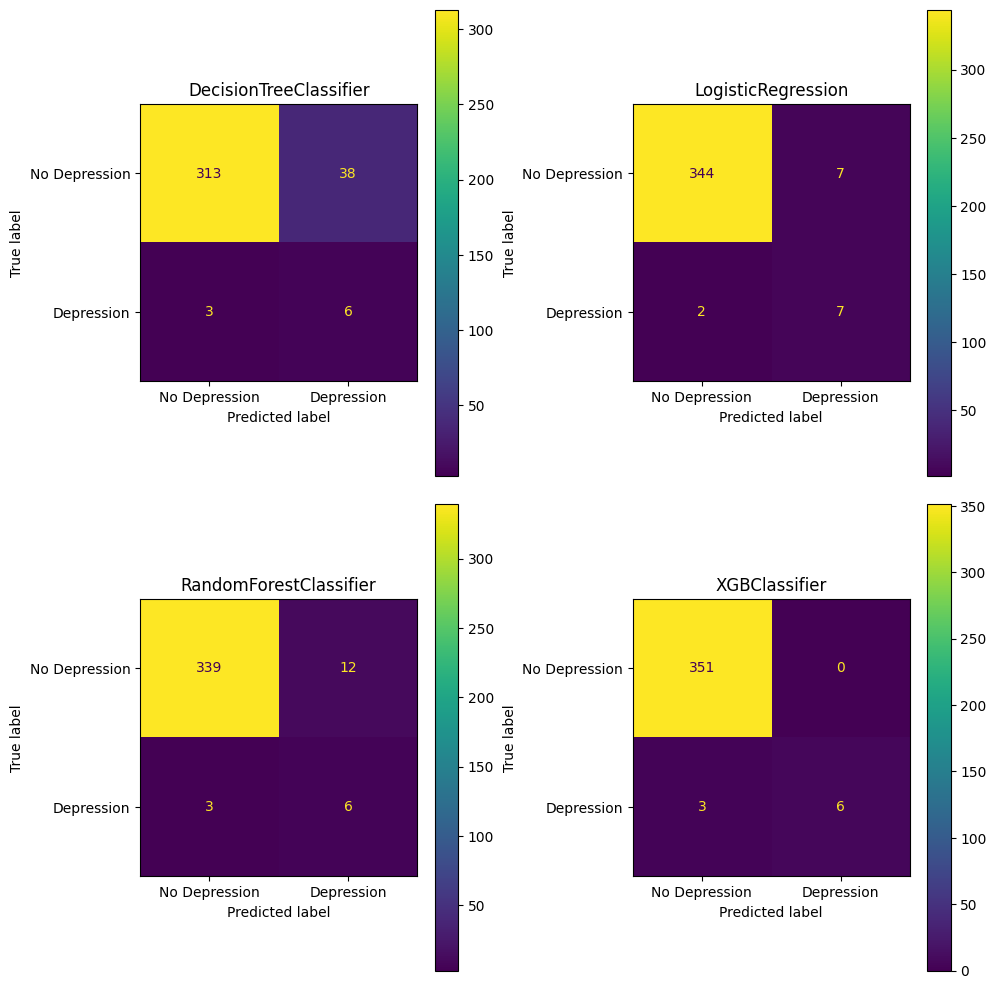

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes = axes.flatten()

for i, model_name in enumerate(Models.keys()):

    ConfusionMatrixDisplay(
        confusion_matrix=cmatrices[i],
        display_labels=["No Depression", "Depression"]
    ).plot(ax=axes[i])

    axes[i].set_title(f"{model_name}")

plt.tight_layout()
plt.show()

Important metrics for classification

In [ ]:
models_metrics.sort_values(by="F1_Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1_Score
3,XGBClassifier,0.991667,1.000000,0.666667,0.800000
1,LogisticRegression,0.975000,0.500000,0.777778,0.608696
2,RandomForestClassifier,0.958333,0.333333,0.666667,0.444444
0,DecisionTreeClassifier,0.886111,0.136364,0.666667,0.226415
